<a href="https://colab.research.google.com/github/martinacssll/chemoinformatics/blob/main/MOOC_assignments/chemical_space_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chemical space visualization

In this exercise, you will build your own chemical space visualizations using datasets from the Zenodo record at https://zenodo.org/records/18678356. The record contains a data/ folder containing *outputs of different molecular generators*. This data is the output used in our recent paper [cite:fil], which you are welcome to skim through for more details. Look at the data for the **Glucocorticoid receptor** (focus only on the *_10k* sets for the dissimilarity split, use all output sets indexed 0-4) and compare the chemical spaces covered by the *DrugEx_GT_epsilon_0.6* and *GB_GA_mut_r_0.5*. The goal is to <u>compare how these two different generators explore chemical space relative to the reference chemistry</u>. The *reference chemistry set* can be found in the ChEMBL database for the Glucocorticoid receptor (CHEMBL2034).

### Learning goals

- Load molecular datasets into Python.
- Convert molecules into **descriptor vectors** or **fingerprints** with *RDKit*.
- Use *scikit-learn* to compute **PCA**, **t-SNE** or other visualizations.
- Compare reference chemistry and generated chemistry.
- Interpret differences in coverage, clustering, overlap, and outliers.

### Recommended dataset selection

1. Download the archive from the Zenodo page and inspect the data/ folder to find the designated data sets above.

2. You can use the *ChEMBL Python API* to download the reference chemistry for the Glucocorticoid receptor.

### Suggested workflow

1. Create a Python environment with RDKit, scikit-learn, pandas, matplotlib, and seaborn.

2. Inspect the downloaded files and determine whether each selected dataset is stored as SMILES tables, CSV files, or SDF files.

3. Load the molecules with RDKit. For SMILES-based files, read the table and convert the SMILES strings with Chem.MolFromSmiles. For SDF files, use Chem.SDMolSupplier.

4. Remove invalid molecules and duplicates so that all datasets are processed consistently.

5. Generate a common molecular representation for all selected datasets.

> i. Start with **Morgan fingerprints** such as radius 2 and 2048 bits because they are widely used in chemical similarity analysis.

> ii. Optionally build a second representation based on **physicochemical descriptors** such as molecular weight, logP, TPSA, hydrogen bond donor count, hydrogen bond acceptor count, and rotatable bond count (can be calculated with RDKit).

8. For non-binary descriptor vectors, *standardize* the features before dimensionality reduction.

9. Use scikit-learn **PCA** to generate a first 2D plot.

10. Use scikit-learn **t-SNE** to generate a second 2D plot from the same representation.

11. Color each point by *dataset origin* so that the sets can be compared directly.

12. Save the plots and write a short (two page max) report of what is similar and what is different across the datasets (reports will be discussed during the practical in person workshop).

> However, treat the above as a suggested workflow. You are welcome to explore other representations, similarity measures, and projection methods. You are also welcome to use coding agents to help you with the implementation, but make sure to understand what the code is doing and be able to explain it in your report. You can also consider making the visualizations interactive with Plotly or Bokeh to display molecules on hover, but this is optional.

## 0. Setup and datasets

- Create a Python environment with RDKit, scikit-learn, pandas, matplotlib, and seaborn.

In [ ]:
# Download RDKit and the ChEMBL API
!pip -q install RDKit
!pip -q install chembl_webresource_client

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, Descriptors, rdMolDescriptors, QED
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem.Draw import MolsToGridImage

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from bokeh.plotting import figure, show
from bokeh.models import HoverTool, ColumnDataSource
from bokeh.io import output_notebook
from rdkit.Chem import Draw
import base64
from io import BytesIO

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Data cleaning

The datasets are cleaned in the *QSAR_model.ipynb* notebook. The following cell just uploads the final datasets.

In [ ]:
df_denovo_clean = pd.read_csv('drive/MyDrive/data/df_denovo_clean.csv')
print(f"df_denovo_clean: {len(df_denovo_clean)} entries")
df_refchem_clean = pd.read_csv('drive/MyDrive/data/df_refchem_clean.csv')
print(f"df_refchem_clean: {len(df_refchem_clean)} entries")

data_clean = [(df_refchem_clean, 'Reference chemistry'), (df_denovo_clean, 'De novo')]

df_denovo_clean: 99876 entries
df_refchem_clean: 1460 entries


In [ ]:
# Generate the Mol objects
df_refchem_clean["mol"] = df_refchem_clean["canonical_smiles"].apply(Chem.MolFromSmiles)
df_denovo_clean["mol"] = df_denovo_clean["canonical_smiles"].apply(Chem.MolFromSmiles)

In [ ]:
df_denovo_clean.head()

,mol,canonical_smiles,source
0,<rdkit.Chem.rdchem.Mol object at 0x789edd18ec00>,Cc1cccc(N(CC(C)C)C(=O)COC(=O)c2ccc3c(c2)COC(C2...,DrugEx_GT
1,<rdkit.Chem.rdchem.Mol object at 0x789edd18ec70>,Cc1cc(-c2ccc(C(C)COCc3ccccc3)c3cc[nH]c23)c(C=N...,DrugEx_GT
2,<rdkit.Chem.rdchem.Mol object at 0x789edd18ece0>,CC(=CC=C1C=CC(C)(c2ccccn2)CO1)C1C(=N)N1C(C1CC1...,DrugEx_GT
3,<rdkit.Chem.rdchem.Mol object at 0x789edd18ed50>,CC#CC1(O)CCC2C3CCC4=CC(=O)CCC4=C3C(c3ccc(CNCCO...,DrugEx_GT
4,<rdkit.Chem.rdchem.Mol object at 0x789edd18edc0>,CC(C)CC(O)(Cc1cc2cc(-c3ccccc3S(N)(=O)=O)ncc2[n...,DrugEx_GT


In [ ]:
df_refchem_clean.head()

,mol,canonical_smiles,pIC50,molecule_chembl_id
0,<rdkit.Chem.rdchem.Mol object at 0x789edb43e7a0>,C#CC1(O)CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@@H]4[C@...,6.826814,CHEMBL2107797
1,<rdkit.Chem.rdchem.Mol object at 0x789edb43e810>,C#CC1=C(SCC(=O)c2ccccc2)NC(C)=C(C(C)=O)C1c1cccs1,5.730487,CHEMBL5267245
2,<rdkit.Chem.rdchem.Mol object at 0x789edb43e880>,C#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@@H]4...,6.363512,CHEMBL1162
3,<rdkit.Chem.rdchem.Mol object at 0x789edb43e8f0>,C#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@]4(C...,6.679854,CHEMBL241694
4,<rdkit.Chem.rdchem.Mol object at 0x789edb43e960>,C#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=Cc5oncc5C[C@]4(...,5.365120,CHEMBL1479


## 2. Descriptors

Calculate **fingerprints** and **physicochemical descriptors** for all datasets.

- **Fingerprints**: Morgan, radius 2, 2048 bit
- **Physicochemical descriptors**:
  - MW, LogP (or cLogP), TPSA, HBD, HBA
  - Rotatable bonds, aromatic ring count, fraction Csp3
  - Number of rings, heteroatom count
  - QED (drug-likeness score)
  - Formal charge, molar refractivity

In [ ]:
# Fingerprints
def morgan_fingerprints(mol, radius=2, nBits=2048):
    if mol is None:
        return None
    mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=nBits)
    fp = mfpgen.GetFingerprintAsNumPy(mol)  # as numpy array for sklearn
    return fp

for dataset in data_clean:
  df = dataset[0]
  df["fp"] = df["mol"].apply(morgan_fingerprints)

In [ ]:
# Descriptors
def calc_descriptors(mol):
    if mol is None:
        return None
    return pd.Series({
        'MW': Descriptors.MolWt(mol),
        'LogP': Descriptors.MolLogP(mol),
        'TPSA': Descriptors.TPSA(mol),
        'HBD': Descriptors.NumHDonors(mol),
        'HBA': Descriptors.NumHAcceptors(mol),
        'RotBonds': Descriptors.NumRotatableBonds(mol),
        'AromaticRings': rdMolDescriptors.CalcNumAromaticRings(mol),
        'FractionCSP3': rdMolDescriptors.CalcFractionCSP3(mol),
        'RingCount': rdMolDescriptors.CalcNumRings(mol),
        'HeteroatomCount': rdMolDescriptors.CalcNumHeteroatoms(mol),
        'FormalCharge': Chem.GetFormalCharge(mol),
        'MolarRefractivity': Descriptors.MolMR(mol), # higher: larger / more polarizable
    })

print("Calculating reference chemistry dataset")
descriptor_df = df_refchem_clean["mol"].apply(calc_descriptors)
df_refchem_clean = pd.concat([df_refchem_clean.reset_index(drop=True), descriptor_df.reset_index(drop=True)], axis=1)
df_refchem_clean = df_refchem_clean.round(2)

print("Calculating de novo dataset")
descriptor_df = df_denovo_clean["mol"].apply(calc_descriptors)
df_denovo_clean = pd.concat([df_denovo_clean.reset_index(drop=True), descriptor_df.reset_index(drop=True)], axis=1)
df_denovo_clean = df_denovo_clean.round(2)

print("Done")

Calculating reference chemistry dataset
Calculating de novo dataset
Done


In [ ]:
# Drop unused columns and add 'source' column the ChEMBL dataset
df_refchem_clean.drop(columns=['pIC50', 'molecule_chembl_id'], inplace=True)
df_refchem_clean['source'] = 'ChEMBL'

# Concatenate all datasets for PCA and t-SNE, after adding a flag for origin dataset
df_all = pd.concat([df_denovo_clean, df_refchem_clean])
df_all

,mol,canonical_smiles,source,fp,MW,LogP,TPSA,HBD,HBA,RotBonds,AromaticRings,FractionCSP3,RingCount,HeteroatomCount,FormalCharge,MolarRefractivity
0,<rdkit.Chem.rdchem.Mol object at 0x789edd18ec00>,Cc1cccc(N(CC(C)C)C(=O)COC(=O)c2ccc3c(c2)COC(C2...,DrugEx_GT,"[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",493.64,6.01,65.07,0.0,5.0,7.0,2.0,0.53,4.0,6.0,0.0,140.48
1,<rdkit.Chem.rdchem.Mol object at 0x789edd18ec70>,Cc1cc(-c2ccc(C(C)COCc3ccccc3)c3cc[nH]c23)c(C=N...,DrugEx_GT,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",512.65,6.13,98.07,4.0,5.0,7.0,4.0,0.34,5.0,6.0,0.0,150.97
2,<rdkit.Chem.rdchem.Mol object at 0x789edd18ece0>,CC(=CC=C1C=CC(C)(c2ccccn2)CO1)C1C(=N)N1C(C1CC1...,DrugEx_GT,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",496.60,4.73,92.07,2.0,4.0,10.0,1.0,0.54,5.0,8.0,0.0,133.36
3,<rdkit.Chem.rdchem.Mol object at 0x789edd18ed50>,CC#CC1(O)CCC2C3CCC4=CC(=O)CCC4=C3C(c3ccc(CNCCO...,DrugEx_GT,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",475.63,4.01,78.79,3.0,5.0,5.0,1.0,0.57,5.0,5.0,0.0,135.23
4,<rdkit.Chem.rdchem.Mol object at 0x789edd18edc0>,CC(C)CC(O)(Cc1cc2cc(-c3ccccc3S(N)(=O)=O)ncc2[n...,DrugEx_GT,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",441.48,3.76,109.07,3.0,4.0,6.0,3.0,0.35,3.0,10.0,0.0,107.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,<rdkit.Chem.rdchem.Mol object at 0x789edd18e9d0>,O[C@]1(c2ccccc2)CCCC[C@@]12C=Cc1c(cnn1-c1ccc(F...,ChEMBL,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",374.46,5.03,38.05,1.0,2.0,2.0,3.0,0.29,5.0,4.0,0.0,107.50
1456,<rdkit.Chem.rdchem.Mol object at 0x789edd18ea40>,Oc1ccc(-c2ccc3c(cnn3-c3ccc(F)cc3)c2)cc1,ChEMBL,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",304.32,4.54,38.05,1.0,2.0,2.0,4.0,0.00,4.0,4.0,0.0,88.13
1457,<rdkit.Chem.rdchem.Mol object at 0x789edd18eab0>,Oc1ccc(C2=CCCC[C@]23C=Cc2c(cnn2-c2ccc(F)cc2)C3...,ChEMBL,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",372.44,5.54,38.05,1.0,2.0,2.0,3.0,0.21,5.0,4.0,0.0,108.63
1458,<rdkit.Chem.rdchem.Mol object at 0x789edd18eb20>,Oc1cccc(-c2ccc3c(cnn3-c3ccc(F)cc3)c2)c1,ChEMBL,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",304.32,4.54,38.05,1.0,2.0,2.0,4.0,0.00,4.0,4.0,0.0,88.13


#### Subset of the dataset

For computational efficiency and visualization purposes, only a subset of the *de novo* molecules is selected for PCA and t-SNE.

In [ ]:
# Select a subset of the data for computational feasibility
refchem_full = df_all[df_all['source'] == 'ChEMBL']  # keep all

drugex_sample = df_all[df_all['source'] == 'DrugEx_GT'].sample(n=2500, random_state=42) # select some
gbga_sample = df_all[df_all['source'] == 'GB_GA'].sample(n=2500, random_state=42) # select some

df_sample = pd.concat([refchem_full, drugex_sample, gbga_sample], ignore_index=True)

print(df_sample['source'].value_counts())  # confirm number of samples for each dataset
print(f"Total samples: {len(df_sample)}")

source
DrugEx_GT    2500
GB_GA        2500
ChEMBL       1460
Name: count, dtype: int64
Total samples: 6460


In [ ]:
# Check range for each descriptor
descriptor_cols = ['MW', 'LogP', 'TPSA', 'HBD', 'RotBonds', 'AromaticRings', 'FractionCSP3']
df_sample[descriptor_cols].describe()

,MW,LogP,TPSA,HBD,RotBonds,AromaticRings,FractionCSP3
count,6460.000000,6460.000000,6460.000000,6460.000000,6460.000000,6460.000000,6460.000000
mean,437.716091,4.763649,69.150288,1.723529,5.322601,2.350929,0.378560
std,122.724353,1.780279,31.893816,1.109309,2.971082,1.291141,0.178954
min,81.070000,-2.220000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,378.400000,3.720000,46.530000,1.000000,3.000000,1.000000,0.260000
50%,448.610000,4.870000,66.020000,2.000000,5.000000,2.000000,0.360000
75%,511.560000,5.930000,88.850000,2.000000,7.000000,3.000000,0.480000
max,992.330000,12.860000,272.690000,9.000000,21.000000,7.000000,1.000000


## 3. Chemical Space Visualization: PCA, t-SNE

- **PCA**:
  - *Linear*: finds axes (linear combinations of your original features) that capture maximum variance
  - *Global structure*: preserves overall variance/spread — distances between far-apart points are meaningful
  - *Deterministic*: same input always gives the same output
  - *Interpretable*: you can look at loadings (e.g. "PC1 is mostly MW + LogP") and explain what each axis means chemically
  - *Fast*, scales well

- **t-SNE**:
  - *Non-linear*: models local neighborhood similarity, tries to preserve which points are close together
  - *Local structure*: great at revealing clusters/groups; global distances between clusters are not meaningful
  - *Stochastic*: different runs (different random seeds) can give different-looking layouts, though relative clustering tends to be stable
  - *Not interpretable*: axes have no chemical meaning
  - *Sensitive to hyperparameters*, especially perplexity

### From fingerprints

#### a. PCA

In [ ]:
# PCA
# X values: DataFrame of the features in columns turned to a numpy array
X = np.stack(df_sample['fp'].values)  # shape: (n_samples, 2048)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)
# pca_result: numpy array of shape (n_samples, n_components), transformed coordinates of each sample in the PC space

df_sample['PC1_fp'] = pca_result[:, 0]
df_sample['PC2_fp'] = pca_result[:, 1]

print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")

Explained variance: PC1=5.50%, PC2=3.68%


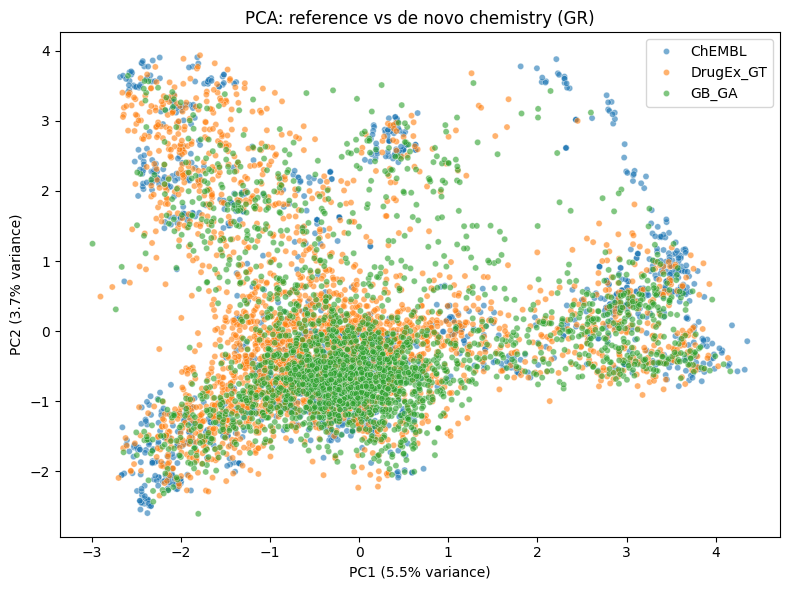

In [ ]:
# Plot data in PC space
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_sample, x='PC1_fp', y='PC2_fp', hue='source', alpha=0.6, s=20)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA: reference vs de novo chemistry (GR)')
plt.legend()
plt.tight_layout()

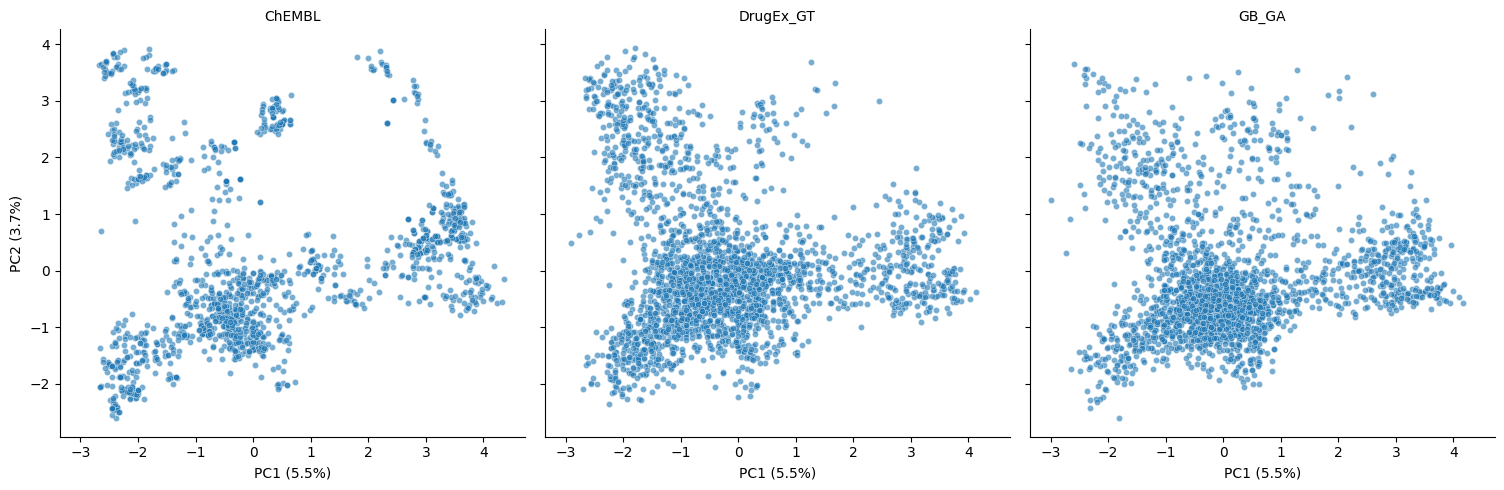

In [ ]:
# Plot each dataset in a separate panel
g = sns.FacetGrid(df_sample, col='source', height=5, col_wrap=4)
g.map_dataframe(sns.scatterplot, x='PC1_fp', y='PC2_fp', alpha=0.6, s=20)
g.set_axis_labels(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})',
                   f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
g.set_titles(col_template='{col_name}')
plt.tight_layout()

In [ ]:
# Plot with molecules visualized on hover
output_notebook()

def mol_to_base64(mol, size=(200, 200)):
    if mol is None:
        return None
    img = Draw.MolToImage(mol, size=size)
    buffered = BytesIO()
    img.save(buffered, format="PNG")
    img_str = base64.b64encode(buffered.getvalue()).decode()
    return f"data:image/png;base64,{img_str}"

df_sample['mol_img'] = df_sample['mol'].apply(mol_to_base64)

source = ColumnDataSource(df_sample[['PC1_fp', 'PC2_fp', 'source', 'mol_img']])

p = figure(width=700, height=500, title="PCA: reference vs de novo chemistry (GR)")
p.scatter('PC1_fp', 'PC2_fp', source=source, size=8, alpha=0.6)

hover = HoverTool(tooltips="""
    <div>
        <img src="@mol_img" width="150"><br>
        <span>@source</span>
    </div>
""")
p.add_tools(hover)

show(p)

#### b. t-SNE

In [ ]:
# t-SNE
# Calculate on a subset of the data for computational feasibility
X_fp = np.stack(df_sample['fp'].values)  # shape (n_samples, 2048)

print("Computing t-SNE")

tsne = TSNE(
    n_components=2,
    metric='jaccard',
    init='random',        # required - 'pca' init isn't supported with non-euclidean metrics
    perplexity=30,
    method='barnes_hut',  # approximation required for anything beyond a few thousand points; exact method doesn't scale
    random_state=42,
    n_jobs=1              # use all CPU cores to help with runtime
)
tsne_result = tsne.fit_transform(X_fp)
print("Done computing t-SNE")

df_sample['tSNE1_fp'] = tsne_result[:, 0]
df_sample['tSNE2_fp'] = tsne_result[:, 1]

Computing t-SNE


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


Done computing t-SNE


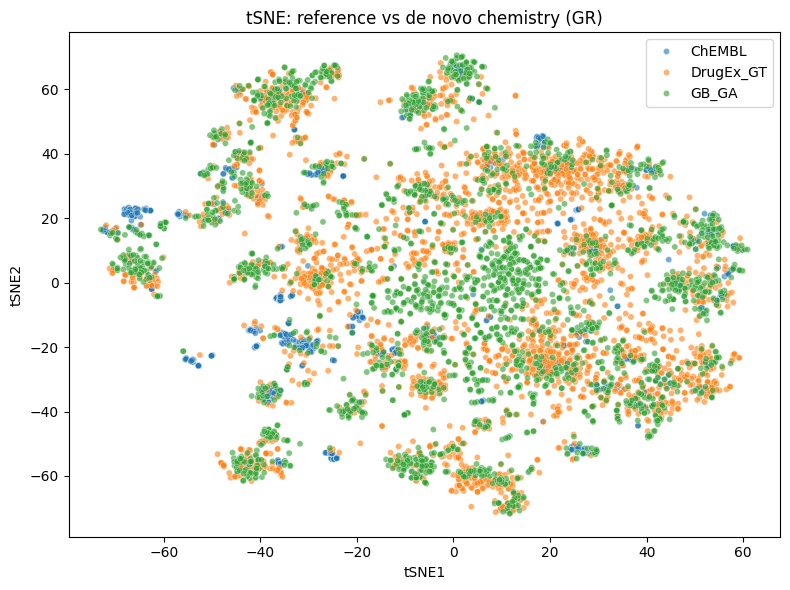

In [ ]:
# Plot data
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_sample, x='tSNE1_fp', y='tSNE2_fp', hue='source', alpha=0.6, s=20)
plt.xlabel(f'tSNE1')
plt.ylabel(f'tSNE2')
plt.title('tSNE: reference vs de novo chemistry (GR)')
plt.legend()
plt.tight_layout()

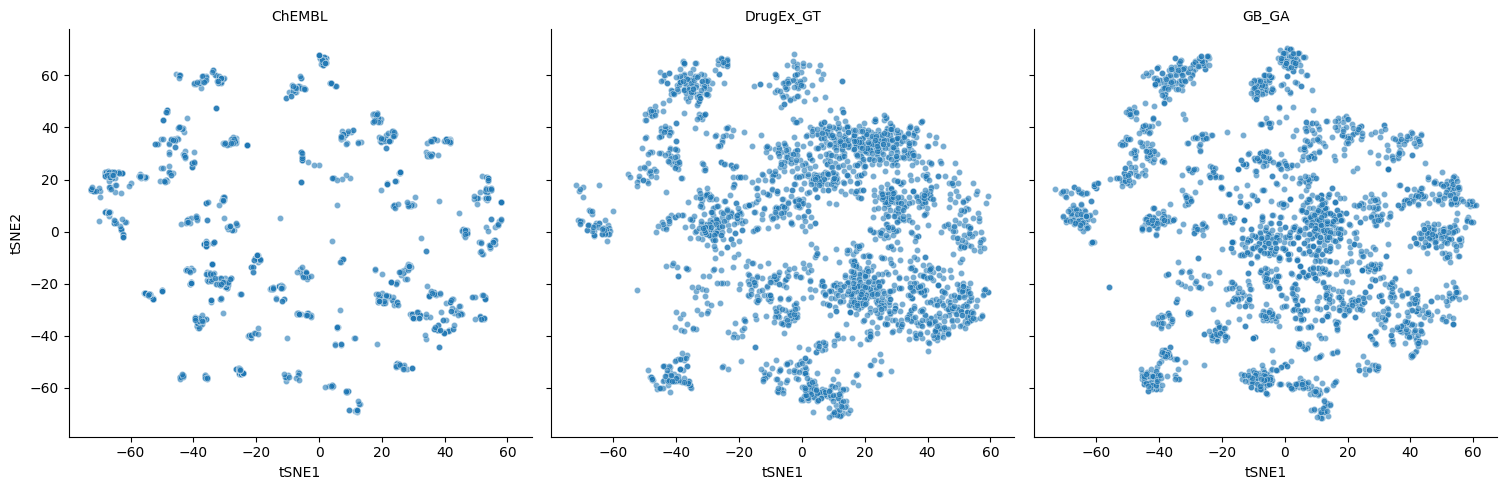

In [ ]:
# Plot each dataset in a separate panel
g = sns.FacetGrid(df_sample, col='source', height=5, col_wrap=4)
g.map_dataframe(sns.scatterplot, x='tSNE1_fp', y='tSNE2_fp', alpha=0.6, s=20)
g.set_axis_labels(f'tSNE1',
                   f'tSNE2')
g.set_titles(col_template='{col_name}')
plt.tight_layout()

In [ ]:
# Plot with molecules visualized on hover
output_notebook()

source = ColumnDataSource(df_sample[['tSNE1_fp', 'tSNE2_fp', 'source', 'mol_img']])

p = figure(width=700, height=500, title="t-SNE: reference vs de novo chemistry(GR)")
p.scatter('tSNE1_fp', 'tSNE2_fp', source=source, size=8, alpha=0.6)

hover = HoverTool(tooltips="""
    <div>
        <img src="@mol_img" width="150"><br>
        <span>@source</span>
    </div>
""")
p.add_tools(hover)

show(p)

### From Descriptors

Check correlation between each descriptor pair, and chose a subset where correlations are < 0.85.

<Axes: >

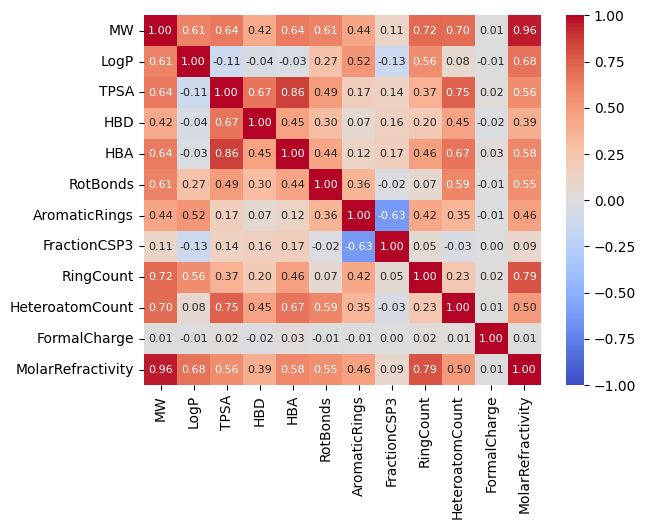

In [ ]:
# Check correlation between all descriptors
descriptor_cols_all = ['MW', 'LogP', 'TPSA',
       'HBD', 'HBA', 'RotBonds', 'AromaticRings', 'FractionCSP3', 'RingCount',
       'HeteroatomCount', 'FormalCharge', 'MolarRefractivity']

corr = df_sample[descriptor_cols_all].corr() # 1: positive corr, 0: no corr, -1: negative corr
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot_kws={'size': 8}, fmt='.2f')

<Axes: >

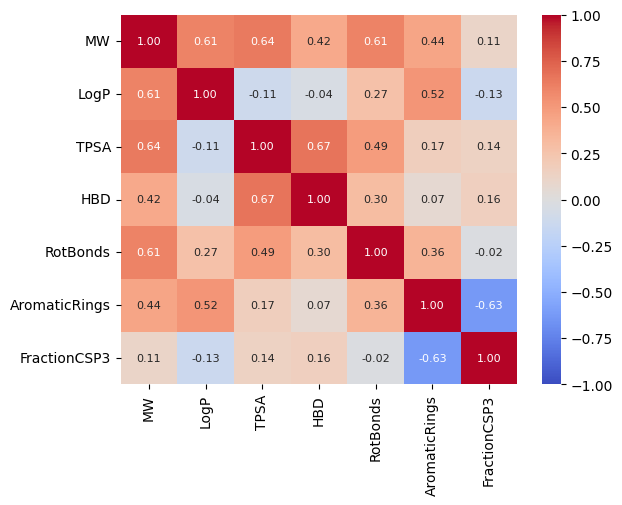

In [ ]:
# Select these descriptors to exclude redundant / highly correlated ones and check correlation between these
descriptor_cols = ['MW', 'LogP', 'TPSA', 'HBD', 'RotBonds', 'AromaticRings', 'FractionCSP3']

corr = df_sample[descriptor_cols].corr() # 1: positive corr, 0: no corr, -1: negative corr
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot_kws={'size': 8}, fmt='.2f')

In [ ]:
df_sample[descriptor_cols].describe()  # check ranges of all selected descriptors

,MW,LogP,TPSA,HBD,RotBonds,AromaticRings,FractionCSP3
count,6460.000000,6460.000000,6460.000000,6460.000000,6460.000000,6460.000000,6460.000000
mean,437.716091,4.763649,69.150288,1.723529,5.322601,2.350929,0.378560
std,122.724353,1.780279,31.893816,1.109309,2.971082,1.291141,0.178954
min,81.070000,-2.220000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,378.400000,3.720000,46.530000,1.000000,3.000000,1.000000,0.260000
50%,448.610000,4.870000,66.020000,2.000000,5.000000,2.000000,0.360000
75%,511.560000,5.930000,88.850000,2.000000,7.000000,3.000000,0.480000
max,992.330000,12.860000,272.690000,9.000000,21.000000,7.000000,1.000000


#### a. PCA

In [ ]:
# PCA
# X values: DataFrame of the features in columns turned to a numpy array
X = df_sample[descriptor_cols].values # shape: (n_samples, n_descriptors)
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
# pca_result: numpy array of shape (n_samples, n_components), transformed coordinates of each sample in the PC space

df_sample['PC1_desc'] = pca_result[:, 0]
df_sample['PC2_desc'] = pca_result[:, 1]

print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")

Explained variance: PC1=41.48%, PC2=26.96%


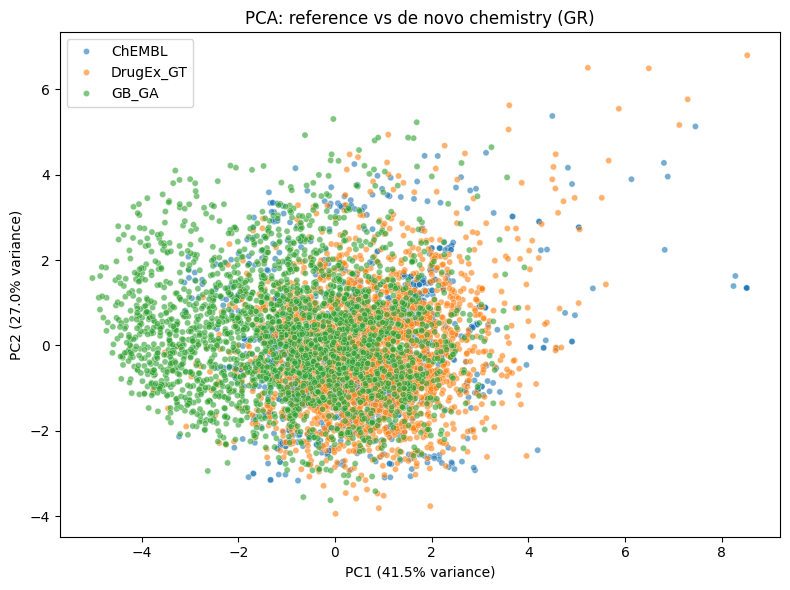

In [ ]:
# Plot data in PC space
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_sample, x='PC1_desc', y='PC2_desc', hue='source', alpha=0.6, s=20)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA: reference vs de novo chemistry (GR)')
plt.legend()
plt.tight_layout()

In [ ]:
# Inspect loadings
loadings = pd.DataFrame(
    pca.components_.T,  # transpose: rows = descriptors, columns = PCs
    columns=['PC1', 'PC2'],
    index=descriptor_cols
)
print(loadings)

                    PC1       PC2
MW             0.535061  0.029146
LogP           0.300753 -0.406398
TPSA           0.424989  0.380222
HBD            0.340713  0.392318
RotBonds       0.443931  0.031974
AromaticRings  0.356180 -0.491729
FractionCSP3  -0.051159  0.541008


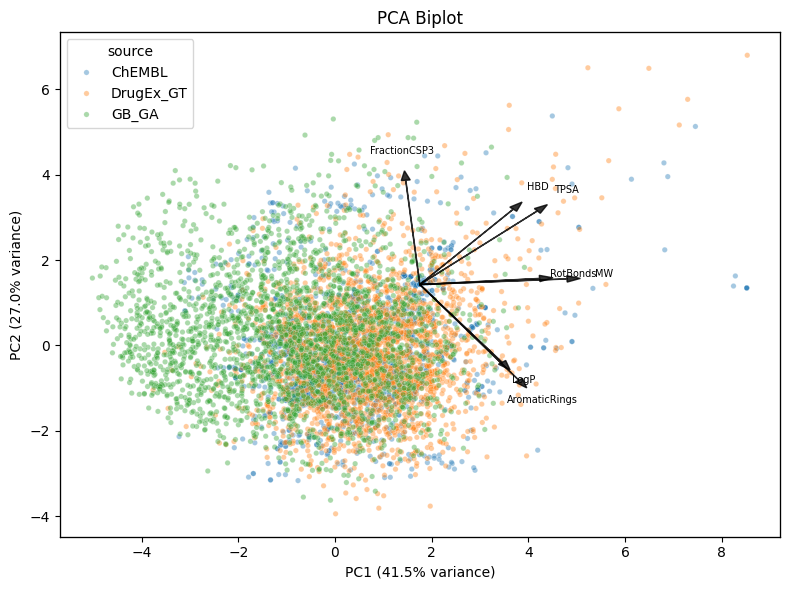

In [ ]:
# Biplot
fig, ax1 = plt.subplots(figsize=(8, 6))

# scatter on primary axis
sns.scatterplot(data=df_sample, x='PC1_desc', y='PC2_desc', hue='source', alpha=0.4, s=15, ax=ax1)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')

# loadings on a secondary, independently-scaled axis
ax2 = ax1.twinx().twiny()
for i, descriptor in enumerate(descriptor_cols):
    ax2.arrow(0, 0, loadings.iloc[i]['PC1'], loadings.iloc[i]['PC2'],
              color='black', alpha=0.8, head_width=0.03, length_includes_head=True)
    ax2.text(loadings.iloc[i]['PC1']*1.15, loadings.iloc[i]['PC2']*1.15,
              descriptor, fontsize=7, ha='center', color='black')

ax2.set_xlim(-1.2, 1.2)
ax2.set_ylim(-1.2, 1.2)
ax2.set_xticks([])
ax2.set_yticks([])

plt.title('PCA Biplot')
plt.tight_layout()
plt.show()

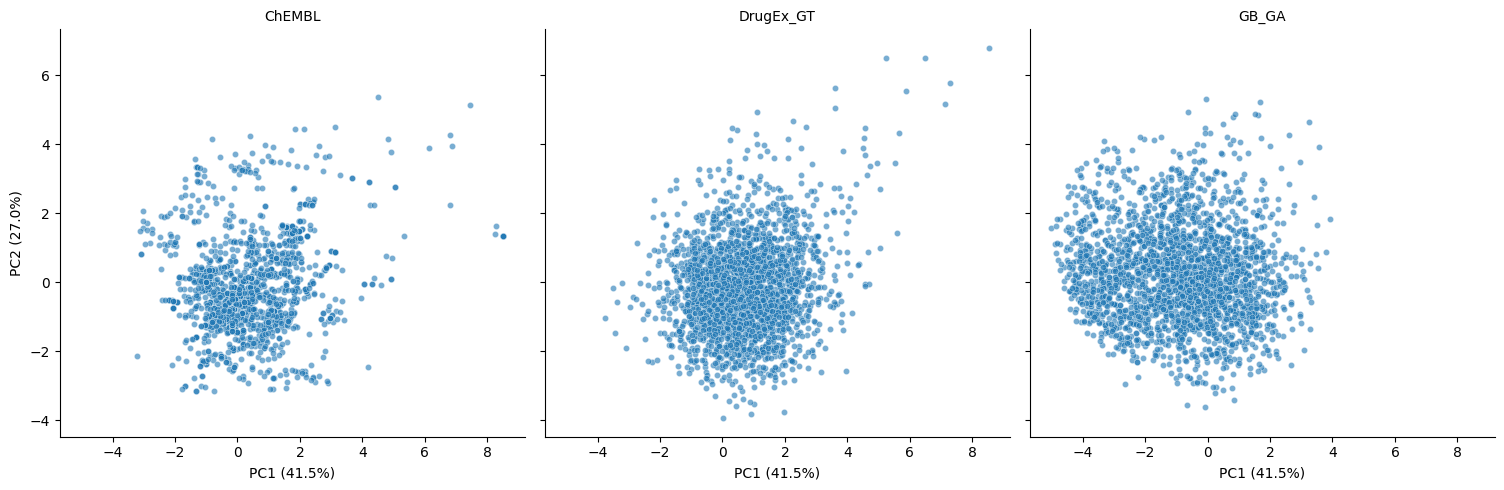

In [ ]:
# Plot each dataset in a separate panel
g = sns.FacetGrid(df_sample, col='source', height=5, col_wrap=4)
g.map_dataframe(sns.scatterplot, x='PC1_desc', y='PC2_desc', alpha=0.6, s=20)
g.set_axis_labels(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})',
                   f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
g.set_titles(col_template='{col_name}')
plt.tight_layout()

In [ ]:
# Plot with molecules visualized on hover
output_notebook()

source = ColumnDataSource(df_sample[['PC1_desc', 'PC2_desc', 'source', 'mol_img']])

p = figure(width=700, height=500, title="PCA: reference vs de novo chemistry (GR)")
p.scatter('PC1_desc', 'PC2_desc', source=source, size=8, alpha=0.6)

hover = HoverTool(tooltips="""
    <div>
        <img src="@mol_img" width="150"><br>
        <span>@source</span>
    </div>
""")
p.add_tools(hover)

show(p)

#### b. t-SNE

In [ ]:
# t-SNE
# Calculate on a subset of the data for computational feasibility
X = df_sample[descriptor_cols].values  # use the MW-filtered dataframe
X_scaled = StandardScaler().fit_transform(X)  # scaling

print("Computing t-SNE")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=1)
tsne_result = tsne.fit_transform(X_scaled)
print("Done computing t-SNE")

df_sample['tSNE1_desc'] = tsne_result[:, 0]
df_sample['tSNE2_desc'] = tsne_result[:, 1]

Computing t-SNE
Done computing t-SNE


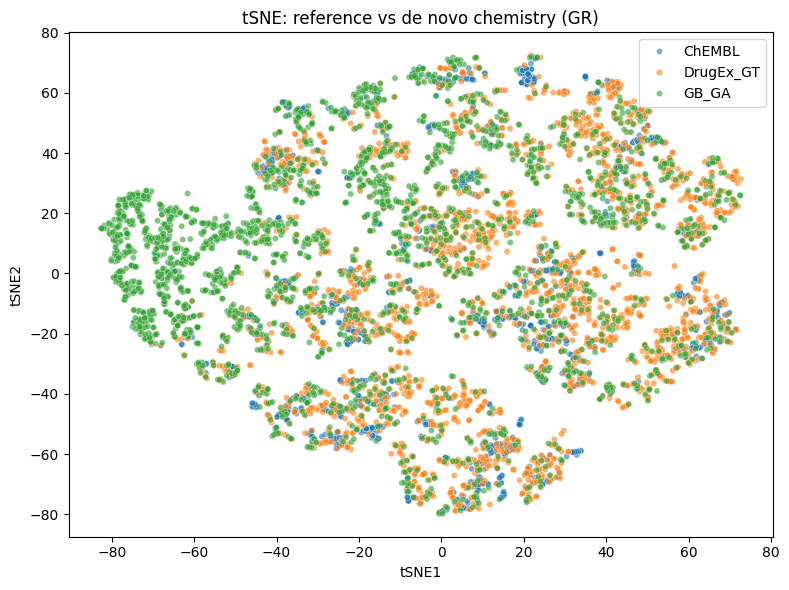

In [ ]:
# Plot data
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_sample, x='tSNE1_desc', y='tSNE2_desc', hue='source', alpha=0.6, s=20)
plt.xlabel(f'tSNE1')
plt.ylabel(f'tSNE2')
plt.title('tSNE: reference vs de novo chemistry (GR)')
plt.legend()
plt.tight_layout()

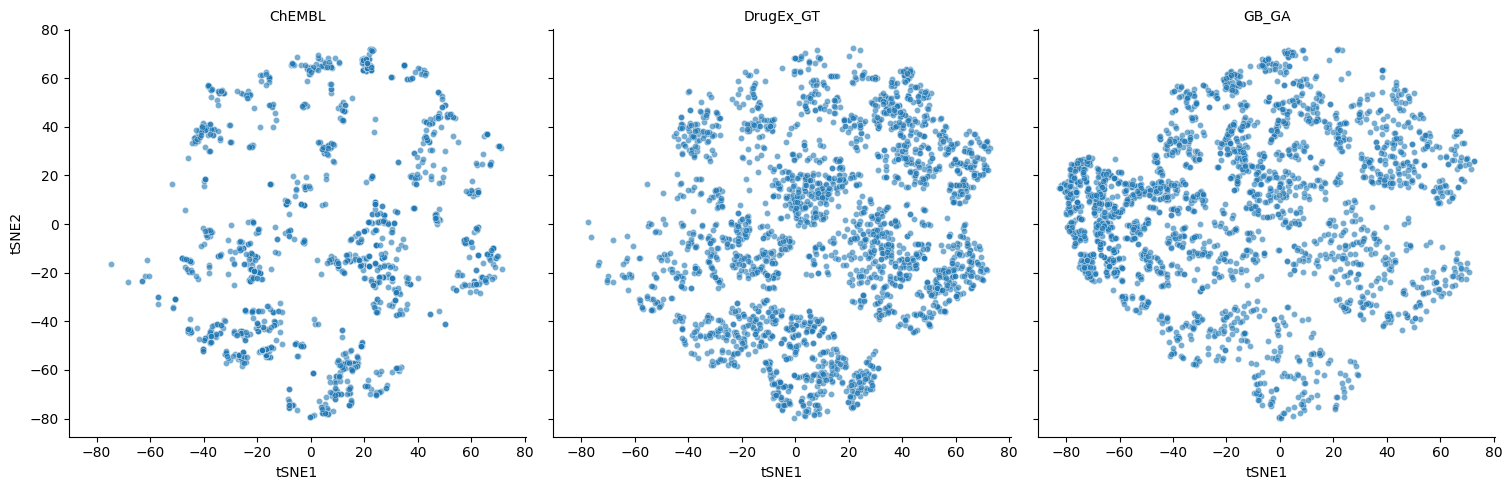

In [ ]:
# Plot each dataset in a separate panel
g = sns.FacetGrid(df_sample, col='source', height=5, col_wrap=4)
g.map_dataframe(sns.scatterplot, x='tSNE1_desc', y='tSNE2_desc', alpha=0.6, s=20)
g.set_axis_labels(f'tSNE1',
                   f'tSNE2')
g.set_titles(col_template='{col_name}')
plt.tight_layout()

In [ ]:
# Plot all df_drug with molecules visualized on hover to check fast what these outliers are
output_notebook()

source = ColumnDataSource(df_sample[['tSNE1_desc', 'tSNE2_desc', 'source', 'mol_img']])

p = figure(width=700, height=500, title="t-SNE: GR approved drugs")
p.scatter('tSNE1_desc', 'tSNE2_desc', source=source, size=8, alpha=0.6)

hover = HoverTool(tooltips="""
    <div>
        <img src="@mol_img" width="150"><br>
        <span>@source</span>
    </div>
""")
p.add_tools(hover)

show(p)

In [ ]:
# Save to a file
df_sample.to_csv('drive/MyDrive/data/df_sample.csv', index=False)

## Questions to answer in the report

1. Which datasets *overlap* strongly, and which are clearly separated?

2. Do the generated sets stay close to *reference chemistry*, or does it explore a different region?

3. Which method, *PCA or t-SNE*, makes the cluster structure easier to see?

4. Do you observe *outliers*, and if so, what might explain them?

5. How does the interpretation change when using *descriptors instead of fingerprints*?